In [20]:
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib_venn import venn2, venn3
from venn import venn as venn_plot
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"


## How does the performance change if i pick mdels based on iptm

In [2]:
benchmark_metrics_ranking = pl.read_parquet(data_dir /"Pipeline/10_all_CP_complexes/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics_benchmark_bigger_complexes.parquet")

In [3]:
# add confidence

benchmark_metrics_iptm = pl.read_parquet(data_dir /"Pipeline/16_CP_model_based_on_iptm/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")

conf = {}
for d in {Path(p).parent for p in benchmark_metrics_iptm["combfold_output_path"]}:
    conf.update(dict(line.split() for line in open(d / "confidence.txt")))

benchmark_metrics_iptm = benchmark_metrics_iptm.with_columns(pl.col("combfold_output_path").map_elements(lambda p: float(conf[p]), return_dtype=pl.Float64).alias("CF_confidence"))

In [4]:
# filetr so both ny have highest confidece 

benchmark_metrics_ranking = (
    benchmark_metrics_ranking
    .sort("CF_confidence", descending=True)
    .group_by("complex_ac", maintain_order=True)
    .first()
)

benchmark_metrics_ranking = benchmark_metrics_ranking.filter(pl.col("n_proteins")> 2)

benchmark_metrics_iptm = (
    benchmark_metrics_iptm
    .sort("CF_confidence", descending=True)
    .group_by("complex_ac", maintain_order=True)
    .first()
)

benchmark_metrics_iptm = benchmark_metrics_iptm.filter(pl.col("n_proteins")> 2)

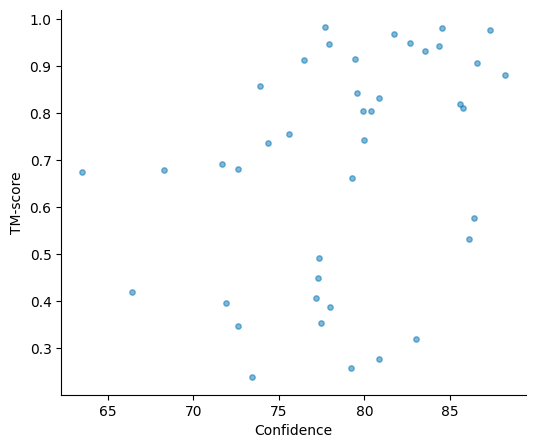

In [5]:
# scatter plot of benchmark_metrics_ranking x:confidenc, y tm score

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    benchmark_metrics_iptm["CF_confidence"],
    benchmark_metrics_iptm["usalign_cpx_tm_score"],
    color="#0072B2", alpha=0.5, s=15,
)
ax.set_xlabel("Confidence")
ax.set_ylabel("TM-score")
ax.spines[["top", "right"]].set_visible(False)


In [6]:
df_ranking = benchmark_metrics_ranking.select(["complex_ac", "usalign_cpx_tm_score"]).rename({"usalign_cpx_tm_score": "usalign_cpx_tm_score_ranking"})
df_iptm = benchmark_metrics_iptm.select(["complex_ac", "usalign_cpx_tm_score"]).rename({"usalign_cpx_tm_score": "usalign_cpx_tm_score_iptm"})

comparison = df_ranking.join(df_iptm, on="complex_ac", how="inner").with_columns(
    tm_score_diff = pl.col("usalign_cpx_tm_score_iptm") - pl.col("usalign_cpx_tm_score_ranking")
)

n_ranking_above = comparison.filter(pl.col("usalign_cpx_tm_score_ranking") > 0.7).height
n_iptm_above = comparison.filter(pl.col("usalign_cpx_tm_score_iptm") > 0.7).height

print("ranking > 0.7:", n_ranking_above)
print("iptm > 0.7:", n_iptm_above)

ranking > 0.7: 23
iptm > 0.7: 22


## how much do pairs differ if i sleect based on iptm/ ranking score

In [27]:
print(data_dir /"Pipeline/16_CP_model_based_on_iptm/16_CP_model_based_on_iptm_pool_pairs_metrics.csv")

/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/16_CP_model_based_on_iptm/16_CP_model_based_on_iptm_pool_pairs_metrics.csv


In [7]:
iptm_pairs = pl.read_csv(data_dir /"Pipeline/16_CP_model_based_on_iptm/16_CP_model_based_on_iptm_pool_pairs_metrics.csv")
rankin_pairs = pl.read_csv(data_dir /"Pipeline/10_all_CP_complexes/10_all_CP_complexes_pool_pairs_metrics.csv")

In [8]:
overlap_complexes = iptm_pairs.select(["complex_ac"]).unique()
rankin_pairs = rankin_pairs.join(overlap_complexes, on="complex_ac", how="inner")

In [9]:
join_cols = ["complex_ac", "pair"]
compare_cols = ["batch_id", "seed", "sample"]

# sanity check: one row per pair per df, otherwise the join will fan out silently
assert iptm_pairs.select(join_cols).is_duplicated().sum() == 0, "df1 not unique on complex_ac+pair"
assert rankin_pairs.select(join_cols).is_duplicated().sum() == 0, "df2 not unique on complex_ac+pair"

merged = iptm_pairs.select(join_cols + compare_cols).join(
    rankin_pairs.select(join_cols + compare_cols),
    on=join_cols,
    how="inner",
    suffix="_df2",
)

merged = merged.with_columns(
    same_model=(
        (pl.col("batch_id") == pl.col("batch_id_df2"))
        & (pl.col("seed") == pl.col("seed_df2"))
        & (pl.col("sample") == pl.col("sample_df2"))
    )
)

n_total = len(merged)
n_same = merged["same_model"].sum()
print(f"{n_same}/{n_total} pairs chose the same model ({100*n_same/n_total:.1f}%)")

# optional: breakdown by pair_type (homo vs hetero) if you join that in too

1340/7980 pairs chose the same model (16.8%)


## checking how much moldes would differ, if I simulate which models get picked

Sanity check based on rnaking, that same pairs were collected from entire pipeline and chosen model sleection simuation (/scripts/Pipeline/select_best_metric_for_input_models)

In [10]:
#ranking
#ranking_models = pl.read_csv(PRJ_ROOT / "scripts/Pipeline/select_best_metric_for_input_models/selection_ranking_score.csv")
#chosen_model_ranking = pl.read_csv(data_dir /"Pipeline/10_all_CP_complexes/10_all_CP_complexes_pool_pairs_metrics_with_plddt_corrected.csv")

'''
iptm
ranking_models = pl.read_csv(PRJ_ROOT / "scripts/Pipeline/select_best_metric_for_input_models/selection_iptm.csv")
chosen_model_ranking = pl.read_csv(data_dir /"Pipeline/16_CP_model_based_on_iptm/16_CP_model_based_on_iptm_pool_pairs_metrics.csv")
 iptm-picking pairs mismatch (~6%) while ranking-picking pairs matched 100%

`s2_run_CombFold.sbatch` sorts candidates by `chain_pair_iptm_corrected` only
(`.sort("chain_pair_iptm_corrected", descending=True, nulls_last=True)`), with
no secondary sort key. `chain_pair_iptm_corrected` has rank-1 ties in ~66% of
contacts, so ties are broken by arbitrary parquet row order.

`01_compare_selection_metrics.py`'s `_rank_and_flag_ties()` breaks ties
deterministically by lowest `sample`
(`.sort(["pair_id", col, "sample"], descending=[False, True, False])`).

`ranking_score` is continuous and essentially never ties exactly, so both
scripts agreed 100%. `chain_pair_iptm_corrected` ties often, so the two
scripts' different tie-break rules disagree on ~6% of picks.
'''

#ptm_avg
ranking_models = pl.read_csv(PRJ_ROOT / "scripts/Pipeline/select_best_metric_for_input_models/selection_ptm_avg.csv")
chosen_model_ranking = pl.read_csv(data_dir /"Pipeline/17_CP_model_based_on_ptm_avg/17_CP_model_based_on_ptm_avg_pool_pairs_metrics.csv")

#pae
#ranking_models = pl.read_csv(PRJ_ROOT / "scripts/Pipeline/select_best_metric_for_input_models/selection_pae.csv")
#chosen_model_ranking = pl.read_csv(data_dir /"Pipeline/18_CP_model_based_on_pae/18_CP_model_based_on_pae_pool_pairs_metrics.csv")

In [11]:
# --- Step 1: dedup chosen_model_ranking on (af3_id1, af3_id2), keep first ---
n_raw = chosen_model_ranking.height

chosen_model_ranking_dedup = chosen_model_ranking.unique(
    subset=["af3_id1", "af3_id2"], keep="first", maintain_order=True
)

n_dedup = chosen_model_ranking_dedup.height
if n_dedup < n_raw:
    print(f"Dedup: dropped {n_raw - n_dedup} duplicate rows "
          f"(same af3_id1/af3_id2), kept first occurrence of each")

# --- Step 2: dedup ranking_models the same way, so the join key set is unambiguous ---
n_ranking_raw = ranking_models.height

ranking_models_dedup = ranking_models.unique(
    subset=["af3_id1", "af3_id2"], keep="first", maintain_order=True
)

n_ranking_dedup = ranking_models_dedup.height
if n_ranking_dedup < n_ranking_raw:
    print(f"Dedup: dropped {n_ranking_raw - n_ranking_dedup} duplicate rows in ranking_models "
          f"(same af3_id1/af3_id2), kept first occurrence of each")

# --- Step 3: semi-join, keep only chosen_model_ranking rows with a matching pair in ranking_models ---
chosen_model_ranking_overlap = chosen_model_ranking_dedup.join(
    ranking_models_dedup.select(["af3_id1", "af3_id2"]),
    on=["af3_id1", "af3_id2"],
    how="semi",
)

n_overlap = chosen_model_ranking_overlap.height

# --- Step 4: check how counts line up ---
print(f"chosen_model_ranking (deduped): {n_dedup} rows")
print(f"ranking_models (deduped):       {n_ranking_dedup} rows")
print(f"overlap after semi-join:        {n_overlap} rows")

if n_overlap < n_dedup:
    n_missing = n_dedup - n_overlap
    print(f"WARNING: {n_missing} deduped chosen_model_ranking rows have no matching "
          f"(af3_id1, af3_id2) pair in ranking_models")

if n_overlap == n_dedup == n_ranking_dedup:
    print("Row counts match exactly across all three — 1:1 correspondence confirmed")
elif n_overlap == n_dedup:
    print("All chosen_model_ranking rows found a match, but ranking_models has extra unmatched pairs")

assert n_overlap > 0, "semi-join dropped everything — check dtypes/whitespace/case on af3_id1/af3_id2"

Dedup: dropped 1141 duplicate rows (same af3_id1/af3_id2), kept first occurrence of each
Dedup: dropped 50 duplicate rows in ranking_models (same af3_id1/af3_id2), kept first occurrence of each
chosen_model_ranking (deduped): 6839 rows
ranking_models (deduped):       6369 rows
overlap after semi-join:        6131 rows


In [12]:
# inner join on the pair key, bringing in both sides' input_name/seed/sample for comparison
compare_df = chosen_model_ranking_dedup.join(
    ranking_models_dedup.select(["af3_id1", "af3_id2", "input_name", "seed", "sample"]),
    on=["af3_id1", "af3_id2"],
    how="inner",
    suffix="_ranking",
)

n_compare = compare_df.height
assert n_compare == n_overlap, \
    f"inner join row count ({n_compare}) doesn't match earlier semi-join overlap ({n_overlap}) — unexpected"

compare_df = compare_df.with_columns([
    (pl.col("input_name") == pl.col("input_name_ranking")).alias("input_name_match"),
    (pl.col("seed") == pl.col("seed_ranking")).alias("seed_match"),
    (pl.col("sample") == pl.col("sample_ranking")).alias("sample_match"),
]).with_columns(
    (pl.col("input_name_match") & pl.col("seed_match") & pl.col("sample_match")).alias("all_match")
)

n_all_match = compare_df["all_match"].sum()
n_input_name_match = compare_df["input_name_match"].sum()
n_seed_match = compare_df["seed_match"].sum()
n_sample_match = compare_df["sample_match"].sum()

print(f"Overlapping pairs: {n_compare}")
print(f"  input_name matches: {n_input_name_match} ({n_input_name_match/n_compare:.1%})")
print(f"  seed matches:       {n_seed_match} ({n_seed_match/n_compare:.1%})")
print(f"  sample matches:     {n_sample_match} ({n_sample_match/n_compare:.1%})")
print(f"  all three match:    {n_all_match} ({n_all_match/n_compare:.1%})")

Overlapping pairs: 6131
  input_name matches: 6087 (99.3%)
  seed matches:       6131 (100.0%)
  sample matches:     6131 (100.0%)
  all three match:    6087 (99.3%)


How similar are chosen pairs  (based on simualted pair picking)

In [13]:
SEL_DIR = PRJ_ROOT / "scripts/Pipeline/select_best_metric_for_input_models"

METRICS = ["ranking_score", "pae", "iptm", "ptm_avg", "ptm_weighted"]
COLORS = {
    "ranking_score": "#0072B2",
    "pae": "#E69F00",
    "iptm": "#009E73",
    "ptm_avg": "#D55E00",
    "ptm_weighted": "#CC79A7",  # 5th color, outside the usual 4-color Okabe-Ito subset
}

In [14]:
ranking_models = pl.read_csv(SEL_DIR / "selection_ranking_score.csv")
pae_models = pl.read_csv(SEL_DIR / "selection_pae.csv")
iptm_models = pl.read_csv(SEL_DIR / "selection_iptm.csv")
ptm_avg_models = pl.read_csv(SEL_DIR / "selection_ptm_avg.csv") #multiple chain copies of P14063 in one row
ptm_weighted_models = pl.read_csv(SEL_DIR / "selection_ptm_weighted.csv")

raw = {
    "ranking_score": ranking_models,
    "pae": pae_models,
    "iptm": iptm_models,
    "ptm_avg": ptm_avg_models,
    "ptm_weighted": ptm_weighted_models,
}

def to_pick_set(df: pl.DataFrame) -> set[tuple]:
    """(pair_id, af3_id1, af3_id2, input_name, seed, sample) for this metric's
    top-1 pick, found contacts only."""
    needed = {"pair_id", "af3_id1", "af3_id2", "input_name", "seed", "sample",
              "status", "model_rank"}
    assert needed.issubset(df.columns), f"missing columns: {needed - set(df.columns)}"
    picks = df.filter((pl.col("status") == "found") & (pl.col("model_rank") == 1))
    return set(zip(
        picks["pair_id"].to_list(),
        picks["af3_id1"].to_list(),
        picks["af3_id2"].to_list(),
        picks["input_name"].to_list(),
        picks["seed"].to_list(),
        picks["sample"].to_list(),
    ))

pick_sets = {name: to_pick_set(df) for name, df in raw.items()}
for name, s in pick_sets.items():
    print(f"{name:14s} {len(s)} top-1 picks")

ranking_score  6368 top-1 picks
pae            6368 top-1 picks
iptm           6368 top-1 picks
ptm_avg        6368 top-1 picks
ptm_weighted   6368 top-1 picks


In [15]:
ranking_models

pair_id,pair_type,protein1,protein2,model_uid,af3_id1,af3_id2,input_type,input_name,batch_id,seed,sample,chain_id1,chain_id2,ranking_score,chain_pair_iptm_corrected,chain_pair_pae_min,ptm_avg,ptm_weighted,model_rank,other_options,status
str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,f64,f64,f64,f64,f64,i64,bool,str
"""o13297__q01159""","""hetero""","""O13297""","""Q01159""","""a8fce36ddf09420e9fabf945a0f0f4…","""o13297""","""q01159""","""pool""","""a8fce36ddf09420e9fabf945a0f0f4…","""26.03/euler-std-a100-r3-2""",4,4,"""A""","""D""",0.357324,0.334321,4.36,0.56,0.554643,1,false,"""found"""
"""o13525__p27680""","""hetero""","""O13525""","""P27680""","""3c4d6423b8aff34da83d64cfa60929…","""o13525""","""p27680""","""pool""","""3c4d6423b8aff34da83d64cfa60929…","""26.03/euler-std-a100-r3-1""",4,0,"""A""","""J""",0.375281,0.012543,28.81,0.6,0.598223,1,false,"""found"""
"""o13525__p41735""","""hetero""","""O13525""","""P41735""","""f5aa9ef0811c79725875eca6064937…","""o13525""","""p41735""","""pool""","""f5aa9ef0811c79725875eca6064937…","""26.01/euler-std-a100-r3-1""",4,0,"""A""","""G""",0.429783,0.449711,4.0,0.62,0.612817,1,false,"""found"""
"""o13525__p49017""","""hetero""","""O13525""","""P49017""","""a336635dc61192795911bbbe1586d1…","""o13525""","""p49017""","""pool""","""a336635dc61192795911bbbe1586d1…","""26.03/euler-std-rtx_pro_6000-r…",4,4,"""A""","""E""",0.379145,0.372983,5.4,0.62,0.617383,1,false,"""found"""
"""o13525__p53318""","""hetero""","""O13525""","""P53318""","""b12d42dc29c563bbb4a63a2ac0aa75…","""o13525""","""p53318""","""pool""","""b12d42dc29c563bbb4a63a2ac0aa75…","""26.03/euler-std-rtx_pro_6000-r…",4,0,"""A""","""H""",0.435879,0.458709,2.91,0.67,0.685921,1,false,"""found"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""q12421__q12421""","""homo""","""Q12421""","""Q12421""","""bf8650305d72e4a670d0fd0f085458…","""q12421""","""q12421""","""pool""","""bf8650305d72e4a670d0fd0f085458…","""26.06/euler-homodimers-rtx_pro…",4,0,"""J""","""K""",0.345736,0.007744,30.01,0.475,0.475,1,false,"""found"""
"""q12438__q12438""","""homo""","""Q12438""","""Q12438""","""87b9708f30d69b5aa74b1b05ad3ac0…","""q12438""","""q12438""","""pool""","""87b9708f30d69b5aa74b1b05ad3ac0…","""26.06/euler-homodimers-rtx_pro…",4,2,"""K""","""L""",0.344697,0.000166,29.63,0.45,0.45,1,false,"""found"""
"""q12464__q12464""","""homo""","""Q12464""","""Q12464""","""f2b1c57e81a2e5d4479bdba7817fc8…","""q12464""","""q12464""","""pool""","""f2b1c57e81a2e5d4479bdba7817fc8…","""26.06/euler-homodimers-rtx_pro…",4,4,"""L""","""M""",0.34278,0.129047,20.46,0.575,0.575,1,false,"""found"""


In [16]:
def chain_only_dupes(df: pl.DataFrame) -> pl.DataFrame:
    """pair_ids where the metric's rank==1 pick has >1 row sharing the same
    model_uid (i.e. same AF3 sample) but different chain_id1/chain_id2."""
    picks = df.filter((pl.col("status") == "found") & (pl.col("model_rank") == 1))
    return (
        picks.group_by(["pair_id", "model_uid"])
        .len()
        .filter(pl.col("len") > 1)
    )


assert all("other_options" in df.columns for df in raw.values()), "other_options column missing somewhere"

# Exclude pair_ids where a metric's rank-1 pick is duplicated across chain copies of the same AF3 sample (multi-copy pooled inputs), which breaks the one-row-per-pair_id assumption below.
bad_pair_ids = set().union(*(set(chain_only_dupes(df)["pair_id"].to_list()) for df in raw.values()))
print(f"Excluding {len(bad_pair_ids)} pair_ids with chain-copy duplicate rank-1 rows")

unambig = {name: df.filter((pl.col("status") == "found") & (pl.col("model_rank") == 1) &
                            (~pl.col("other_options")) & (~pl.col("pair_id").is_in(bad_pair_ids)))
           for name, df in raw.items()}

for name, df in unambig.items():
    print(f"{name:14s} {df.height} unambiguous picks")


#only look at models where not another pair with ran´me ranking metrics exists (e.g other pair had same iptm value, thsoe pairs get kicked out to not skew results)
common_pair_ids = set.intersection(*(set(df["pair_id"].to_list()) for df in unambig.values()))
print(f"\n{len(common_pair_ids)} pair_ids unambiguous across ALL metrics")

assert len(common_pair_ids) > 0, "no pair_ids are unambiguous across all metrics"

unambig_common = {name: df.filter(pl.col("pair_id").is_in(common_pair_ids)) for name, df in unambig.items()}
for name, df in unambig_common.items():
    assert df.height == len(common_pair_ids), f"{name}: expected {len(common_pair_ids)} rows, got {df.height}"

Excluding 19 pair_ids with chain-copy duplicate rank-1 rows
ranking_score  6349 unambiguous picks
pae            6201 unambiguous picks
iptm           2143 unambiguous picks
ptm_avg        2807 unambiguous picks
ptm_weighted   3402 unambiguous picks

926 pair_ids unambiguous across ALL metrics


Text(0.5, 1.0, 'ptm_avg vs ptm_weighted')

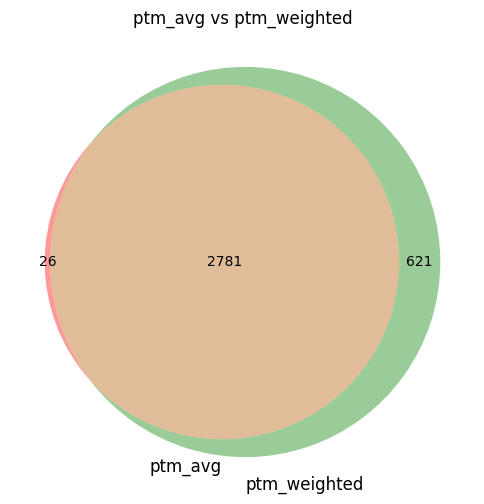

In [17]:
#doe avergaing or length avergaing ptm make a differnce
set_ptm_avg = set(unambig["ptm_avg"]["pair_id"].to_list())
set_ptm_weighted = set(unambig["ptm_weighted"]["pair_id"].to_list())

fig, ax = plt.subplots(figsize=(6, 6))
venn2([set_ptm_avg, set_ptm_weighted], set_labels=("ptm_avg", "ptm_weighted"), ax=ax)
ax.set_title("ptm_avg vs ptm_weighted")


Text(0.5, 1.0, 'Model picks across all 4 metrics')

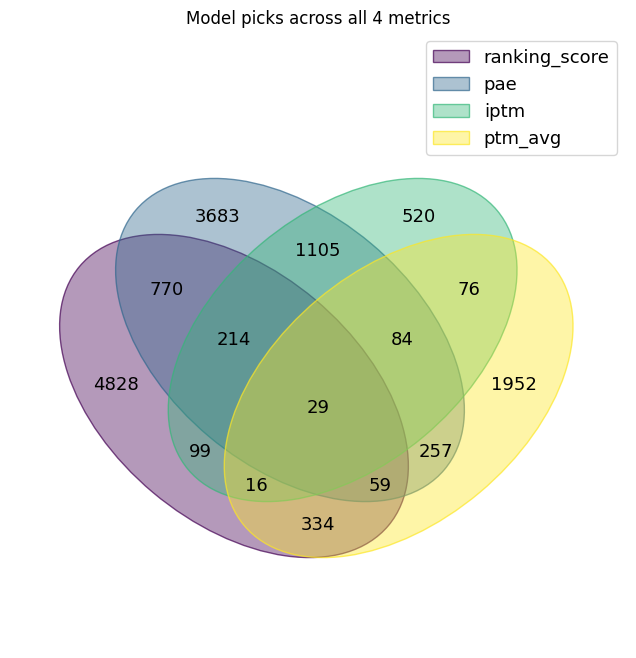

In [21]:
sets_4 = {
    "ranking_score": set(zip(unambig["ranking_score"]["pair_id"].to_list(), unambig["ranking_score"]["model_uid"].to_list())),
    "pae": set(zip(unambig["pae"]["pair_id"].to_list(), unambig["pae"]["model_uid"].to_list())),
    "iptm": set(zip(unambig["iptm"]["pair_id"].to_list(), unambig["iptm"]["model_uid"].to_list())),
    "ptm_avg": set(zip(unambig["ptm_avg"]["pair_id"].to_list(), unambig["ptm_avg"]["model_uid"].to_list())),
}

fig, ax = plt.subplots(figsize=(8, 8))
venn_plot(sets_4, ax=ax)
ax.set_title("Model picks across all 4 metrics")


Text(0.5, 1.0, '(pair_id, model_uid) agreement across metrics (n=926 common pair_ids)')

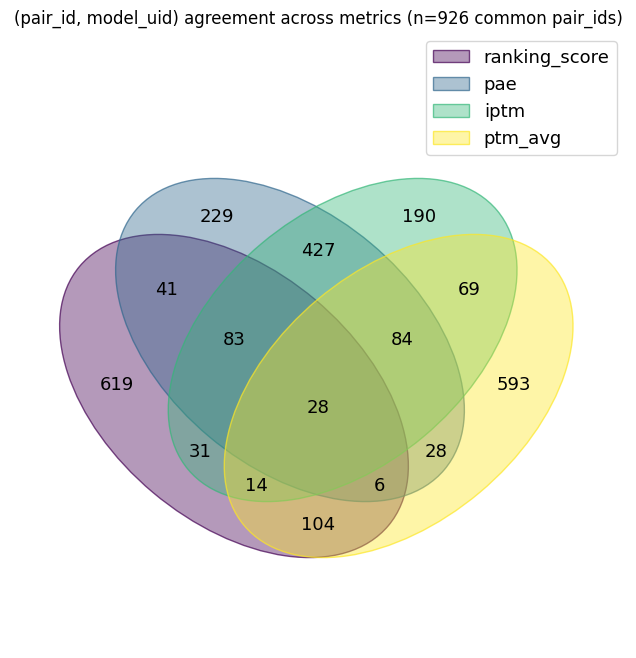

In [22]:
sets_4_by_model = {
    name: set(zip(
        unambig[name].filter(pl.col("pair_id").is_in(common_pair_ids))["pair_id"].to_list(),
        unambig[name].filter(pl.col("pair_id").is_in(common_pair_ids))["model_uid"].to_list(),
    ))
    for name in ("ranking_score", "pae", "iptm", "ptm_avg")
}

for name, s in sets_4_by_model.items():
    assert len(s) == len(common_pair_ids), f"{name}: expected {len(common_pair_ids)} tuples, got {len(s)}"

fig, ax = plt.subplots(figsize=(8, 8))
venn_plot(sets_4_by_model, ax=ax)
ax.set_title(f"(pair_id, model_uid) agreement across metrics (n={len(common_pair_ids)} common pair_ids)")



In [ ]:
"""
def plot_venn(names: list[str], title: str) -> None:
    assert len(names) in (2, 3), "matplotlib_venn only draws 2- or 3-set diagrams"
    for n in names:
        assert n in pick_sets, f"unknown metric {n!r}, have {list(pick_sets)}"
    sets = [pick_sets[n] for n in names]
    colors = [COLORS[n] for n in names]

    fig, ax = plt.subplots(figsize=(6, 6))
    if len(names) == 2:
        venn2(sets, set_labels=names, set_colors=colors, alpha=0.6, ax=ax)
    else:
        venn3(sets, set_labels=names, set_colors=colors, alpha=0.6, ax=ax)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()
"""

## Which metric gives best TM scores

1. load tm files for all metrics
2. add CF confidence
3. keep one eth highest confidence
4. scater plot (still nice threshold determinable)
5. which has most complexes with th >0.7
6. how big tm difference between diff tm choices

In [ ]:
"""
ranking_TM = pl.read_parquet(data_dir /"Pipeline/10_all_CP_complexes/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
iptm_TM = pl.read_parquet(data_dir /"Pipeline/16_CP_model_based_on_iptm/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
ptm_avg_TM = pl.read_parquet(data_dir / "Pipeline/17_CP_model_based_on_ptm_avg/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
pae_TM = pl.read_parquet(data_dir / "Pipeline/18_CP_model_based_on_pae/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
def add_confidence(df):
    conf = {}
    for d in {Path(p).parent for p in df["combfold_output_path"]}:
        conf.update(dict(line.split() for line in open(d / "confidence.txt")))

    df = df.with_columns(pl.col("combfold_output_path").map_elements(lambda p: float(conf[p]), return_dtype=pl.Float64).alias("CF_confidence"))
    return df
"""

In [23]:
def add_confidence(df: pl.DataFrame) -> pl.DataFrame:
    conf = {}
    for d in {Path(p).parent for p in df["combfold_output_path"]}:
        with open(d / "confidence.txt") as f:
            conf.update({k: float(v) for k, v in (line.split() for line in f if line.strip())})

    return df.with_columns(
        pl.col("combfold_output_path")
        .replace_strict(conf, return_dtype=pl.Float64)
        .alias("CF_confidence")
    )

def load(folder: str) -> pl.DataFrame:
    df = add_confidence(
        pl.read_parquet(data_dir / "Pipeline" / folder / "cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
    )
    return (
        df.filter(pl.col("n_proteins") > 2)
        .sort("CF_confidence", descending=True)
        .group_by("complex_ac")
        .first()
    )


ranking_TM, iptm_TM, ptm_avg_TM, pae_TM = map(load, [
    "10_all_CP_complexes",
    "16_CP_model_based_on_iptm",
    "17_CP_model_based_on_ptm_avg",
    "18_CP_model_based_on_pae",
])

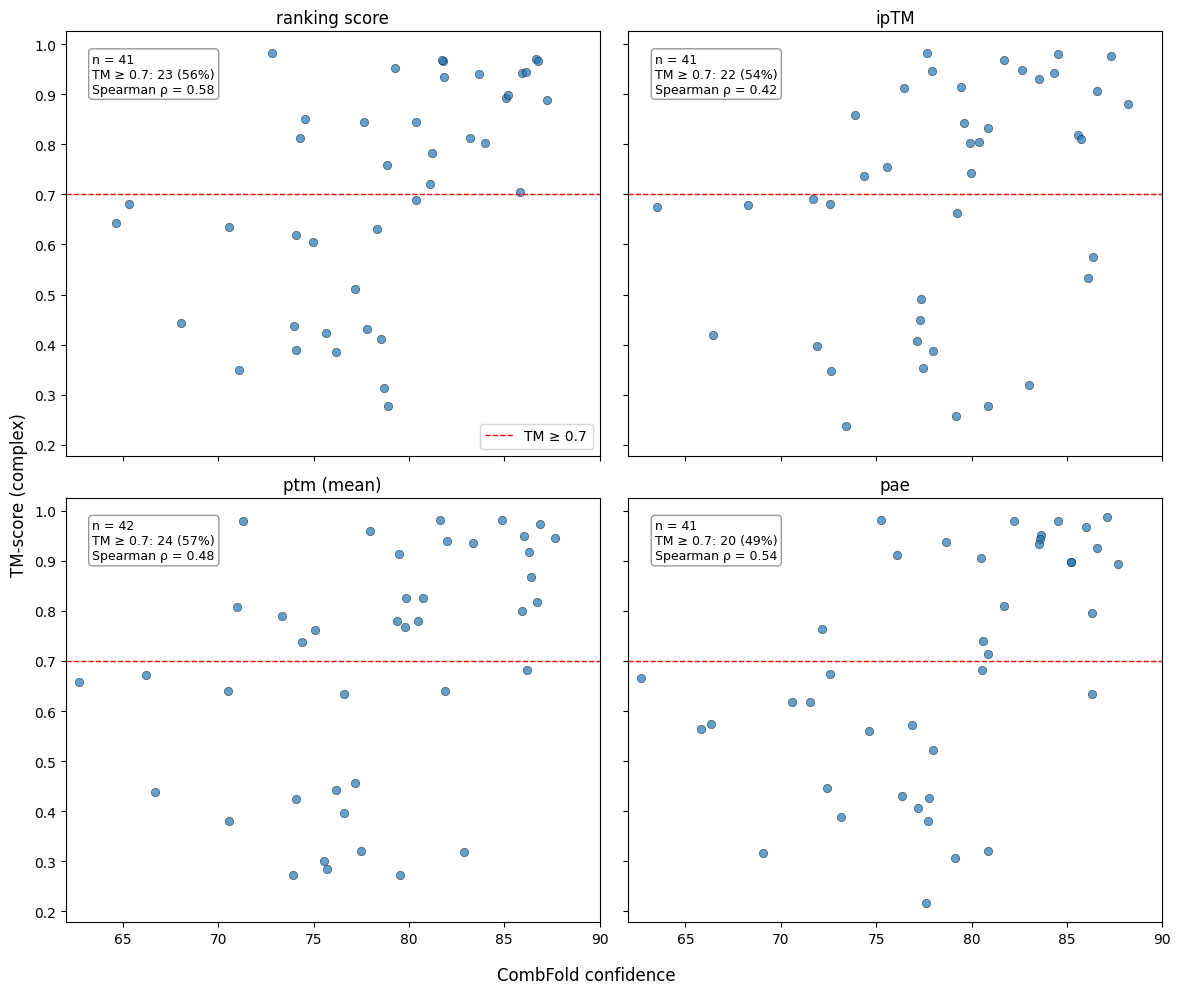

In [24]:
import matplotlib.pyplot as plt
from scipy import stats

dfs = {
    "ranking score":  ranking_TM,
    "ipTM":    iptm_TM,
    "ptm (mean)": ptm_avg_TM,
    "pae":     pae_TM,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for ax, (name, df) in zip(axes.flat, dfs.items()):
    x = df["CF_confidence"].to_numpy()
    y = df["usalign_cpx_tm_score"].to_numpy()
    spearman_r, _ = stats.spearmanr(x, y)
    n_high = (y >= 0.7).sum()

    ax.scatter(x, y, alpha=0.7, edgecolors="k", linewidths=0.4)
    ax.axhline(0.7, color="red", linestyle="--", linewidth=1, label="TM ≥ 0.7")
    ax.set_title(name)
    ax.set_xlim(62, 90)
    ax.annotate(
        f"n = {len(x)}\n"
        f"TM ≥ 0.7: {n_high} ({n_high / len(x):.0%})\n"
        f"Spearman ρ = {spearman_r:.2f}",
        xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )

axes[0, 0].legend(loc="lower right")
fig.supxlabel("CombFold confidence")
fig.supylabel("TM-score (complex)")
fig.tight_layout()
plt.show()

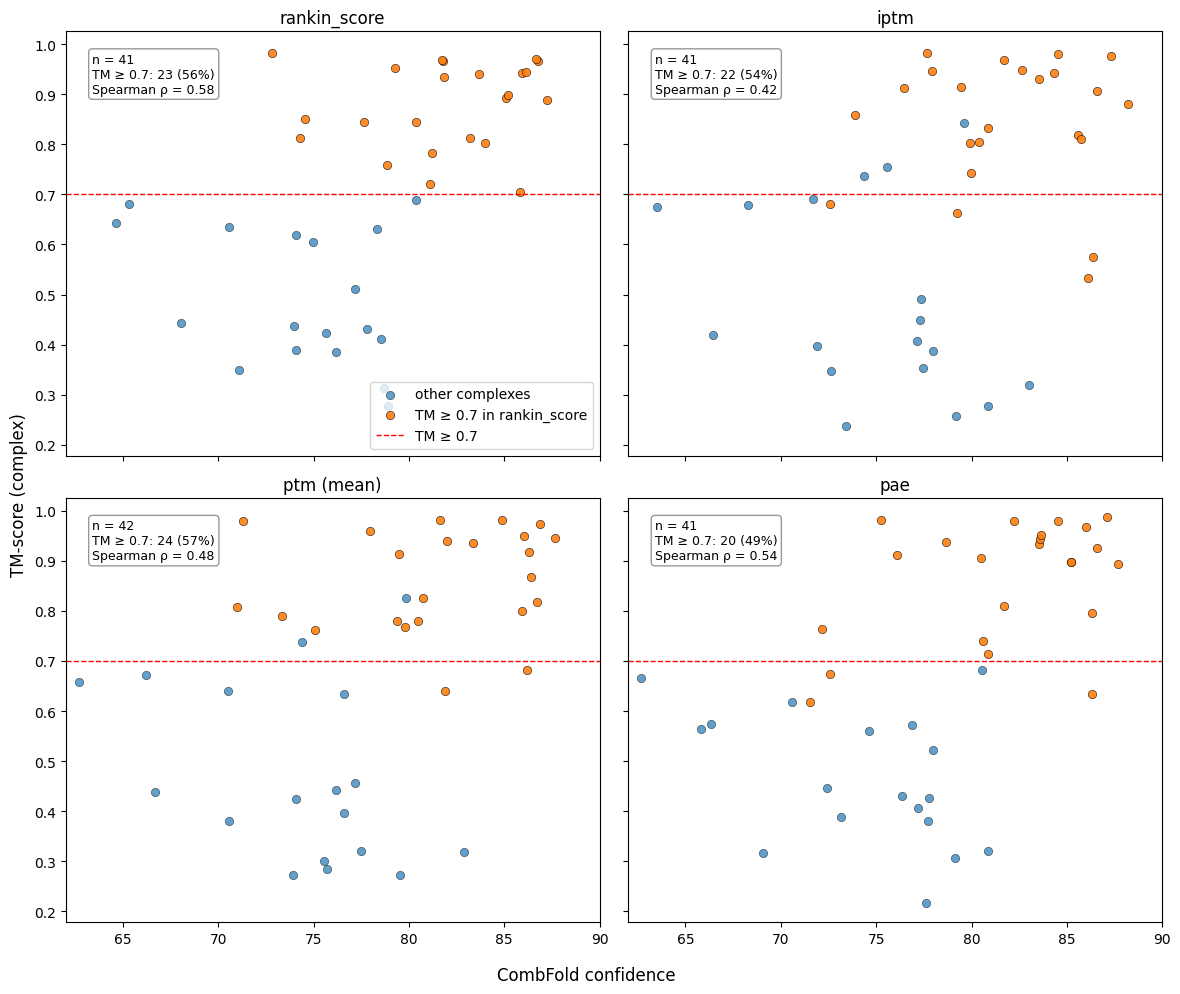

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
from scipy import stats

dfs = {
    "rankin_score": ranking_TM,
    "iptm":         iptm_TM,
    "ptm (mean)":   ptm_avg_TM,
    "pae":          pae_TM,
}

# change only this line: "rankin_score", "iptm", "ptm (mean)" or "pae"
highlight_metric = "rankin_score"

highlight_good = (
    dfs[highlight_metric]
    .filter(pl.col("usalign_cpx_tm_score") >= 0.7)["complex_ac"]
    .to_list()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for ax, (name, df) in zip(axes.flat, dfs.items()):
    x = df["CF_confidence"].to_numpy()
    y = df["usalign_cpx_tm_score"].to_numpy()
    good = df["complex_ac"].is_in(highlight_good).to_numpy()
    spearman_r, _ = stats.spearmanr(x, y)
    n_high = (y >= 0.7).sum()

    ax.scatter(x[~good], y[~good], alpha=0.7, edgecolors="k", linewidths=0.4,
               color="tab:blue", label="other complexes")
    ax.scatter(x[good], y[good], alpha=0.9, edgecolors="k", linewidths=0.4,
               color="tab:orange", label=f"TM ≥ 0.7 in {highlight_metric}")
    ax.axhline(0.7, color="red", linestyle="--", linewidth=1, label="TM ≥ 0.7")
    ax.set_title(name)
    ax.set_xlim(62, 90)
    ax.annotate(
        f"n = {len(x)}\n"
        f"TM ≥ 0.7: {n_high} ({n_high / len(x):.0%})\n"
        f"Spearman ρ = {spearman_r:.2f}",
        xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )

axes[0, 0].legend(loc="lower right")
fig.supxlabel("CombFold confidence")
fig.supylabel("TM-score (complex)")
fig.tight_layout()
plt.show()

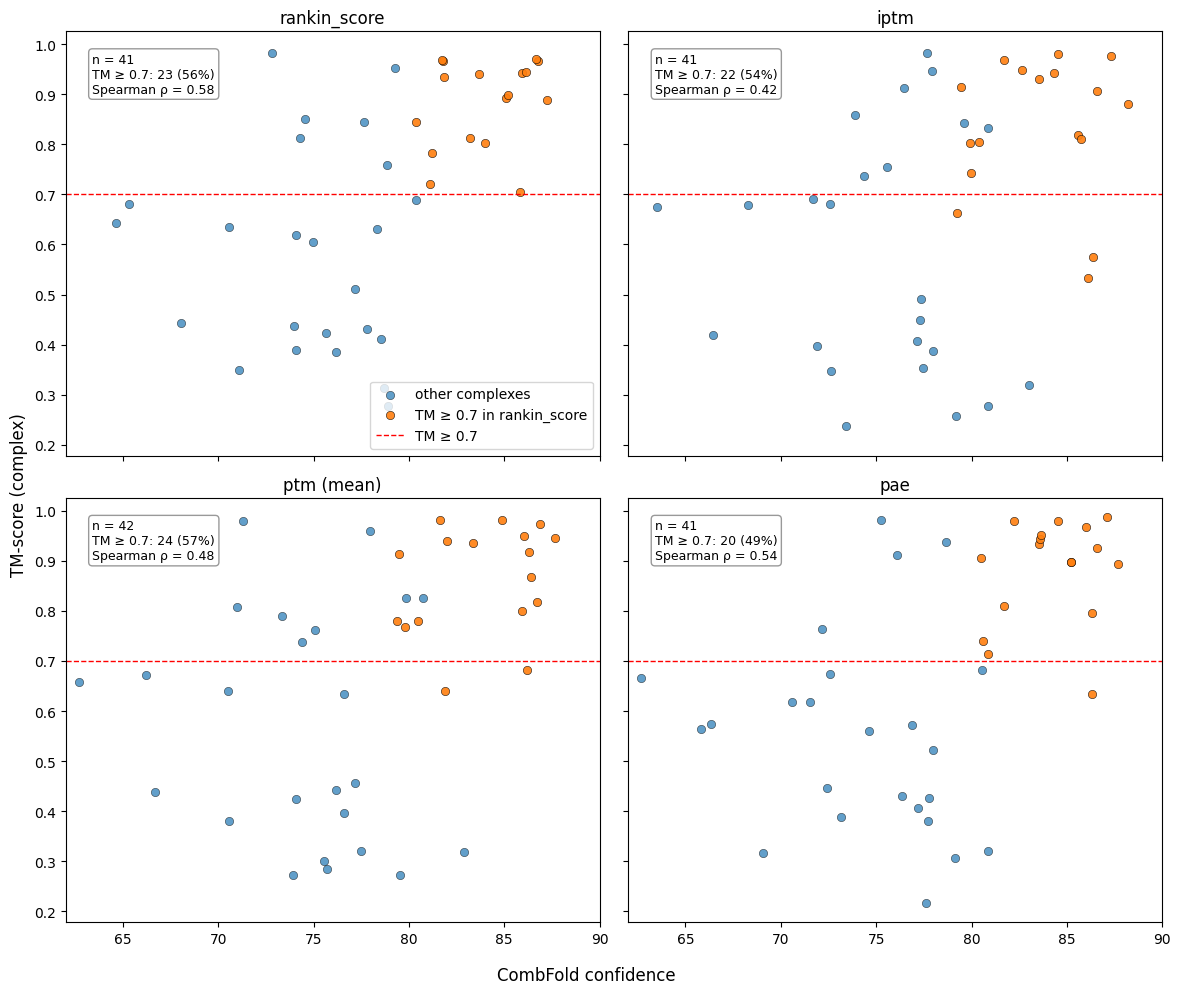

In [ ]:
dfs = {
    "rankin_score": ranking_TM,
    "iptm":         iptm_TM,
    "ptm (mean)":   ptm_avg_TM,
    "pae":          pae_TM,
}

# change only this line: "rankin_score", "iptm", "ptm (mean)" or "pae"
highlight_metric = "rankin_score"

highlight_good = (
    dfs[highlight_metric]
    .filter((pl.col("usalign_cpx_tm_score") >= 0.7) & (pl.col("CF_confidence") > 80))["complex_ac"]
    .to_list()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

for ax, (name, df) in zip(axes.flat, dfs.items()):
    x = df["CF_confidence"].to_numpy()
    y = df["usalign_cpx_tm_score"].to_numpy()
    good = df["complex_ac"].is_in(highlight_good).to_numpy()
    spearman_r, _ = stats.spearmanr(x, y)
    n_high = (y >= 0.7).sum()

    ax.scatter(x[~good], y[~good], alpha=0.7, edgecolors="k", linewidths=0.4,
               color="tab:blue", label="other complexes")
    ax.scatter(x[good], y[good], alpha=0.9, edgecolors="k", linewidths=0.4,
               color="tab:orange", label=f"TM ≥ 0.7 in {highlight_metric}")
    ax.axhline(0.7, color="red", linestyle="--", linewidth=1, label="TM ≥ 0.7")
    ax.set_title(name)
    ax.set_xlim(62, 90)
    ax.annotate(
        f"n = {len(x)}\n"
        f"TM ≥ 0.7: {n_high} ({n_high / len(x):.0%})\n"
        f"Spearman ρ = {spearman_r:.2f}",
        xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
    )

axes[0, 0].legend(loc="lower right")
fig.supxlabel("CombFold confidence")
fig.supylabel("TM-score (complex)")
fig.tight_layout()
plt.show()

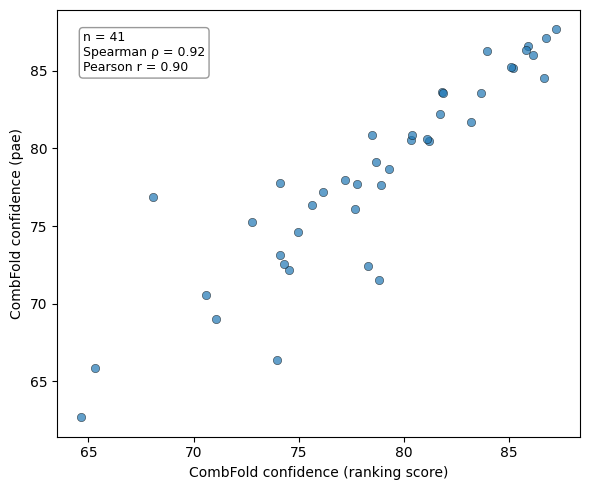

In [25]:
import matplotlib.pyplot as plt
import polars as pl
from scipy import stats

merged = ranking_TM.select("complex_ac", pl.col("CF_confidence").alias("conf_ranking")).join(
    pae_TM.select("complex_ac", pl.col("CF_confidence").alias("conf_pae")),
    on="complex_ac",
    how="inner",
)

x = merged["conf_ranking"].to_numpy()
y = merged["conf_pae"].to_numpy()
rho, p = stats.spearmanr(x, y)
r, _ = stats.pearsonr(x, y)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, alpha=0.7, edgecolors="k", linewidths=0.4)
ax.set_xlabel("CombFold confidence (ranking score)")
ax.set_ylabel("CombFold confidence (pae)")
ax.annotate(
    f"n = {len(x)}\nSpearman ρ = {rho:.2f}\nPearson r = {r:.2f}",
    xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
)
fig.tight_layout()
plt.show()

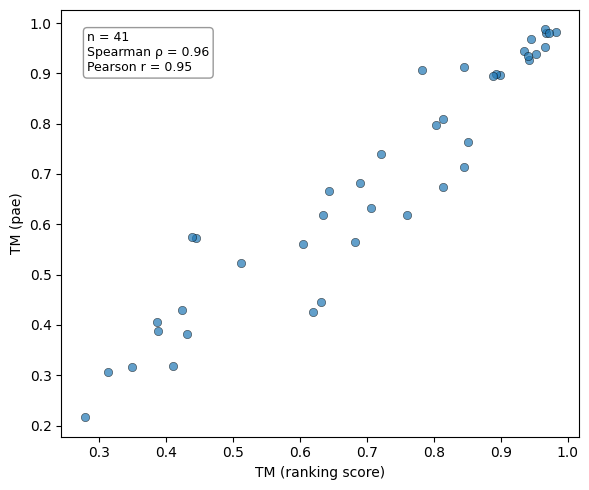

In [26]:
import matplotlib.pyplot as plt
import polars as pl
from scipy import stats

merged = ranking_TM.select("complex_ac", pl.col("usalign_cpx_tm_score").alias("tm_ranking")).join(
    pae_TM.select("complex_ac", pl.col("usalign_cpx_tm_score").alias("tm_pae")),
    on="complex_ac",
    how="inner",
)

x = merged["tm_ranking"].to_numpy()
y = merged["tm_pae"].to_numpy()
rho, p = stats.spearmanr(x, y)
r, _ = stats.pearsonr(x, y)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, alpha=0.7, edgecolors="k", linewidths=0.4)
ax.set_xlabel("TM (ranking score)")
ax.set_ylabel("TM (pae)")
ax.annotate(
    f"n = {len(x)}\nSpearman ρ = {rho:.2f}\nPearson r = {r:.2f}",
    xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8),
)
fig.tight_layout()
plt.show()